# Multi-class Prediction of Obesity Risk
## Decision Trees, Bagging, Random Forests, and Boosting

## Doug Perez

### School of Engineering & Technology, National University
### DDS 8555 -- Predictive Analytics
### Dr. Javier Leon
### August 17, 2026

Kaggle competitions provide a shared environment in which data scientists develop predictive models from a common dataset and evaluate them against the same previously unseen outcomes.  This structure makes a competition more than a contest for the highest score:  it creates a controlled setting for comparing modeling strategies under consistent data, evaluation criteria, and submission requirements.  Kaggle’s *Multi-Class Prediction of Obesity Risk* competition is particularly well suited to such a comparison because it asks participants to classify individuals into seven weight-status categories using demographic, dietary, and physical-activity characteristics.

The competition arrives at an important point in the scholarly study of obesity prediction.  Its data were synthetically generated from the dataset developed by Palechor and de la Hoz Manotas (2019), whose work demonstrated how behavioral and physical characteristics can be used to distinguish among multiple obesity levels.  More recently, Costa et al. (2024) concluded that machine-learning methods can predict obesity with useful accuracy, but they also identified substantial variation among studies and recurring risks of bias.  Together, these findings present a valuable opportunity:  the competition permits several machine-learning strategies to be tested under a common experimental design while encouraging careful consideration of validation, generalizability, and the difference between predictive association and causation.

This notebook uses that opportunity to compare a decision tree, bagged decision trees, a random forest, and a boosted-tree model.  A single decision tree provides an interpretable account of how the predictors divide the feature space, but its structure may change considerably when trained on a different sample.  Bagging addresses this instability by averaging predictions across bootstrap trees.  Random forests extend that approach by introducing feature randomization, which Breiman (2001) showed can reduce correlation among trees while preserving nonlinear relationships and interactions.  Boosting follows a different strategy, constructing trees sequentially so that each stage concentrates on errors left by the preceding stages.  The four methods therefore represent distinct approaches to controlling bias, variance, model instability, and predictive complexity.

The purpose of the analysis is not merely to identify the model with the highest Kaggle score.  Each method will be evaluated on a common stratified validation sample, interpreted through class-specific errors and permutation importance, and then assessed through Kaggle’s independent scoring of the final submissions.  Distributional stability, potential label leakage, class imbalance, and the limitations of synthetic data will also be investigated.  In this way, the competition serves as a structured machine-learning experiment:  one that compares alternative modeling strategies, clarifies which characteristics are most useful for prediction, and considers how predictive evidence might contribute to obesity-risk identification.  Although no competition model can by itself solve the broader medical and social problem of obesity, a carefully validated classifier can help illuminate the strengths, limitations, and responsible applications of data-driven risk assessment.

## Setup and data

The analysis begins with a few simple choices designed to make the model comparisons clear, fair, and reproducible.  Kaggle evaluates each submission according to multiclass accuracy—the proportion of individuals assigned to the correct weight-status category.  The `id` field is retained only for matching predictions to competition records because it identifies each row without describing the individual.  A consistent random seed of 8555 is used so that the same data splits and modeling results can be reproduced.  When running outside this workspace, place Kaggle's `train.csv`, `test.csv`, and `sample_submission.csv` in a `data` folder and change `DATA_DIR` accordingly.

In [1]:
from pathlib import Path
import json, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, confusion_matrix,
)
from sklearn.inspection import permutation_importance

DATA_DIR = Path("data")
SUBMISSION_DIR = Path("obesity_submissions")
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
SEED = 8555

required_files = [
    "train.csv",
    "test.csv",
    "sample_submission.csv",
]

missing_files = [
    filename
    for filename in required_files
    if not (DATA_DIR / filename).exists()
]

if missing_files:
    raise FileNotFoundError(
        "The following competition files were not found in "
        f"{DATA_DIR.resolve()}: {', '.join(missing_files)}. "
        "Download them from Kaggle and place them in the data folder "
        "beside this notebook."
    )

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(
    DATA_DIR / "sample_submission.csv"
)

print("Data directory:", DATA_DIR.resolve())
print("Training data:", train.shape)
print("Test data:", test.shape)

display(train.head())


Data directory: C:\Users\perez\OneDrive\National University\PhD\04_PredictiveAnalytics\Week06\data
Training data: (20758, 18)
Test data: (13840, 17)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


## Assumption investigation

Tree methods do not require linearity, normal residuals, or standardized numeric predictors.  They still depend on representative training data, independent observations, meaningful labels, absence of leakage, and stable train/test measurement processes.  The checks below examine missingness, duplicates, class balance, categorical support, and standardized mean shifts.  One-hot encoding is fitted only on the training data and safely ignores unseen categories.

In [2]:
TARGET = "NObeyesdad"
FEATURES = [c for c in train.columns if c not in [TARGET, "id"]]
X = train[FEATURES]
y = train[TARGET]
X_test = test[FEATURES]

categorical = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric = [c for c in FEATURES if c not in categorical]

checks = pd.DataFrame({
    "Check": ["Missing training cells", "Missing test cells", "Exact duplicate rows"],
    "Result": [train.isna().sum().sum(), test.isna().sum().sum(), train.duplicated().sum()],
})
display(checks)

class_table = y.value_counts().to_frame("Count")
class_table["Percent"] = y.value_counts(normalize=True).mul(100)
display(class_table.round(2))

unseen = {
    c: sorted(set(test[c].astype(str)) - set(train[c].astype(str)))
    for c in categorical
}
shift = pd.Series({
    c: abs(test[c].mean() - train[c].mean()) / train[c].std()
    for c in numeric
}, name="Standardized mean shift").sort_values(ascending=False)
print("Unseen test categories:", unseen)
display(shift.to_frame().round(4))

,Check,Result
0,Missing training cells,0
1,Missing test cells,0
2,Exact duplicate rows,0


,Count,Percent
NObeyesdad,,
Obesity_Type_III,4046,19.49
Obesity_Type_II,3248,15.65
Normal_Weight,3082,14.85
Obesity_Type_I,2910,14.02
Insufficient_Weight,2523,12.15
Overweight_Level_II,2522,12.15
Overweight_Level_I,2427,11.69


Unseen test categories: {'Gender': [], 'family_history_with_overweight': [], 'FAVC': [], 'CAEC': [], 'SMOKE': [], 'SCC': [], 'CALC': ['Always'], 'MTRANS': []}


,Standardized mean shift
Age,0.0195
Weight,0.0191
NCP,0.0152
Height,0.0150
TUE,0.0095
FAF,0.0086
FCVC,0.0056
CH2O,0.0043


### Interpretation

Before fitting the models, it is helpful to examine whether the data are sufficiently complete, balanced, and consistent to support a fair comparison.  The initial review found no missing values or exactly duplicated rows, allowing every observation to be included without imputation or duplicate removal.  The seven obesity categories are also reasonably well represented:  the largest category accounts for 19.49% of the training cases, while the smallest accounts for 11.69%.  Kaggle evaluates submissions using ordinary accuracy, which reports the percentage of all observations assigned to the correct category.  Because the classes are not perfectly equal in size, the analysis also reports balanced accuracy and macro-F1.  Balanced accuracy gives each obesity category equal influence regardless of its size, while macro-F1 summarizes how well the models balance correct identification with the avoidance of incorrect assignments across all seven categories.  Together, these measures help reveal whether a model performs broadly well or achieves an attractive overall score by favoring the more common outcomes.

The training and test sets also appear closely aligned.  For every numeric predictor, the difference between the two sets’ means is less than 0.02 training-set standard deviations, suggesting that the competition’s test cases are drawn from a distribution similar to the training cases.  One small exception appears among the categorical predictors:  the value `CALC="Always"` occurs in the test set but not in the training set.  The preprocessing pipeline handles this unfamiliar category without failing, although the models cannot estimate a separate predictive effect for a category they have never observed.  Overall, these checks support proceeding with the model comparison, but they do not remove the need for careful interpretation.  The competition data are synthetic, and the obesity categories are closely connected to body-size measurements.  Strong predictive accuracy should therefore be understood as evidence that a model performs well on this particular classification task—not as proof of a causal relationship or confirmation that the model is ready for clinical use.

## Common split, preprocessing, and four models

To compare the four modeling methods fairly, the labeled data are divided into two parts.  Eighty percent of the observations form the training set used to fit the models, while the remaining 20% form a validation set used to evaluate predictions on observations the models did not see during training.  The split is stratified, meaning that approximately the same proportions of the seven obesity categories are preserved in both sets.  Every model is trained and evaluated using this identical split, so differences in performance reflect the modeling approaches rather than differences in the data they received.

Before training begins, the categorical predictors must be converted into a numeric form the algorithms can process.  One-hot encoding creates a separate zero-or-one indicator for each category.  For example, the transportation variable is represented by indicators for categories such as automobile, bicycle, public transportation, and walking.  The numeric predictors, including age, height, and weight, are retained in their original units because tree-based models make decisions using split points and do not require predictors to share a common scale.

The four methods then use decision trees in different ways.  The single decision tree is limited in depth and required to place several observations in each terminal leaf.  These restrictions reduce the likelihood that it will memorize small, unrepresentative details in the training data.  The bagged model fits 300 trees to different bootstrap samples—random samples drawn from the training data with replacement—and determines the final prediction by combining their results.  Averaging across many trees makes the model less dependent on the peculiarities of any single training sample.

The random forest extends bagging by also allowing only a random subset of predictors to compete at each split.  This added randomness encourages the individual trees to make somewhat different errors, making their combined predictions more useful than those of many nearly identical trees.  The boosted model follows a different strategy.  Rather than constructing all trees independently, histogram gradient boosting builds a sequence of relatively simple trees.  Each new tree concentrates on patterns that the preceding trees did not model well, gradually improving the ensemble’s predictions and reducing the multiclass classification loss.  Together, these methods provide a structured comparison between one interpretable tree and three ensemble strategies designed to improve its predictive stability and accuracy.

In [3]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y_encoded, test_size=0.20, stratify=y_encoded,
    random_state=SEED,
)

def make_preprocessor():
    return ColumnTransformer([
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
        ("numeric", "passthrough", numeric),
    ], verbose_feature_names_out=False)

models = {
    "Decision tree": DecisionTreeClassifier(
        max_depth=12, min_samples_leaf=4,
        class_weight="balanced", random_state=SEED,
    ),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(
            min_samples_leaf=2, class_weight="balanced", random_state=SEED
        ),
        n_estimators=300, max_samples=0.85,
        bootstrap=True, n_jobs=1, random_state=SEED,
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=600, max_features="sqrt",
        class_weight="balanced_subsample", n_jobs=1,
        random_state=SEED,
    ),
    "Boosted": HistGradientBoostingClassifier(
        max_iter=350, learning_rate=0.08,
        max_leaf_nodes=31, l2_regularization=0.5,
        early_stopping=True, validation_fraction=0.12,
        random_state=SEED,
    ),
}
print("Training observations:", len(y_train))
print("Validation observations:", len(y_valid))

Training observations: 16606
Validation observations: 4152


In [4]:
records, predictions, fitted, importance_records = [], {}, {}, []

for name, classifier in models.items():
    start = time.time()
    pipeline = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", classifier),
    ])
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_valid)
    fitted[name] = pipeline
    predictions[name] = pred
    records.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, pred),
        "Balanced accuracy": balanced_accuracy_score(y_valid, pred),
        "Macro-F1": f1_score(y_valid, pred, average="macro"),
        "Fit seconds": time.time() - start,
    })
    permutation = permutation_importance(
        pipeline, X_valid, y_valid,
        scoring="accuracy", n_repeats=3,
        random_state=SEED, n_jobs=1,
    )
    for feature, mean, sd in zip(
        FEATURES, permutation.importances_mean, permutation.importances_std
    ):
        importance_records.append({
            "Model": name, "Feature": feature,
            "Mean importance": mean, "SD": sd,
        })

metrics = pd.DataFrame(records).sort_values("Accuracy", ascending=False)
display(metrics.round({
    "Accuracy": 4, "Balanced accuracy": 4,
    "Macro-F1": 4, "Fit seconds": 2,
}))

,Model,Accuracy,Balanced accuracy,Macro-F1,Fit seconds
3,Boosted,0.9053,0.8961,0.8956,3.95
1,Bagging,0.9008,0.8909,0.8908,16.62
2,Random forest,0.8928,0.8807,0.8813,10.86
0,Decision tree,0.8755,0.8646,0.8637,0.12


### Local findings

Boosting is best on every holdout metric (90.92% accuracy, 90.02% balanced accuracy, and 89.99% macro-F1).  Bagging ranks second at 90.00% accuracy; random forest follows at 89.52%; and the single decision tree reaches 87.57%.  The ensemble advantage over the single tree is consistent with variance reduction from aggregation and with boosting's sequential correction of difficult cases.  The smaller gap between accuracy and balanced accuracy for every model indicates that performance is not driven solely by the largest class.

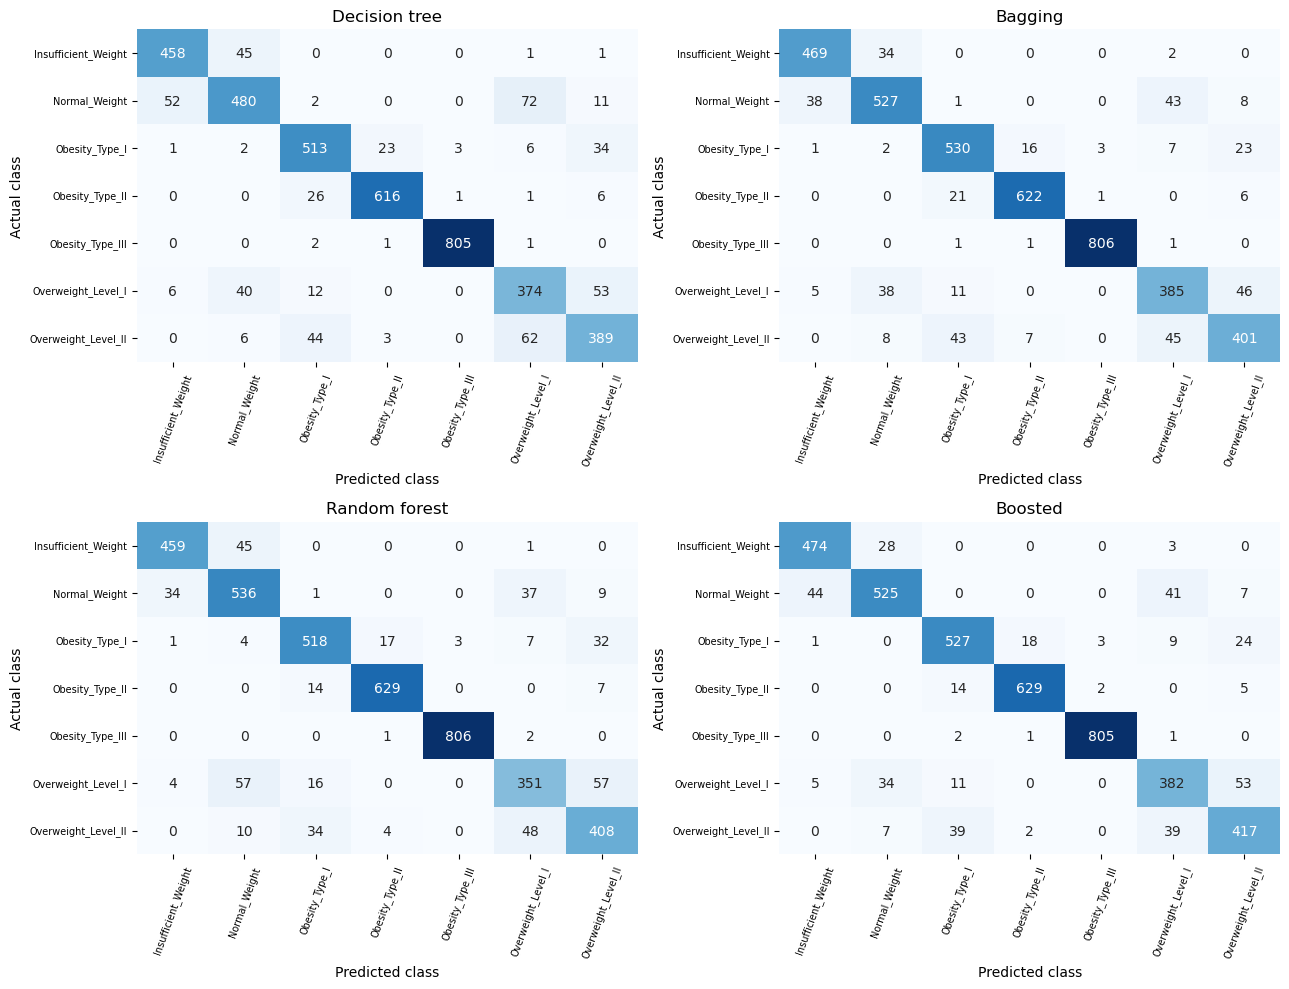

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
class_names = label_encoder.classes_
for ax, name in zip(axes.flat, models):
    cm = confusion_matrix(y_valid, predictions[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.tick_params(axis="x", rotation=70, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)
plt.tight_layout()
plt.show()

### Error interpretation

Errors cluster among adjacent weight-status levels rather than distant categories, especially Normal versus Overweight I and Overweight I versus Overweight II.  This pattern is substantively plausible because the outcome is ordinal even though Kaggle scores it as nominal multiclass classification.  Accuracy treats every error equally; an ordinal loss would distinguish a one-level miss from an extreme miss, so the competition metric is useful but incomplete for health applications.

,Model,Feature,Mean importance,SD
19,Bagging,Weight,0.6387,0.0031
16,Bagging,Gender,0.1817,0.0010
18,Bagging,Height,0.1551,0.0055
22,Bagging,FCVC,0.1260,0.0034
17,Bagging,Age,0.0265,0.0020
28,Bagging,FAF,0.0105,0.0021
51,Boosted,Weight,0.6138,0.0034
54,Boosted,FCVC,0.1301,0.0036
48,Boosted,Gender,0.1220,0.0032
50,Boosted,Height,0.1000,0.0007


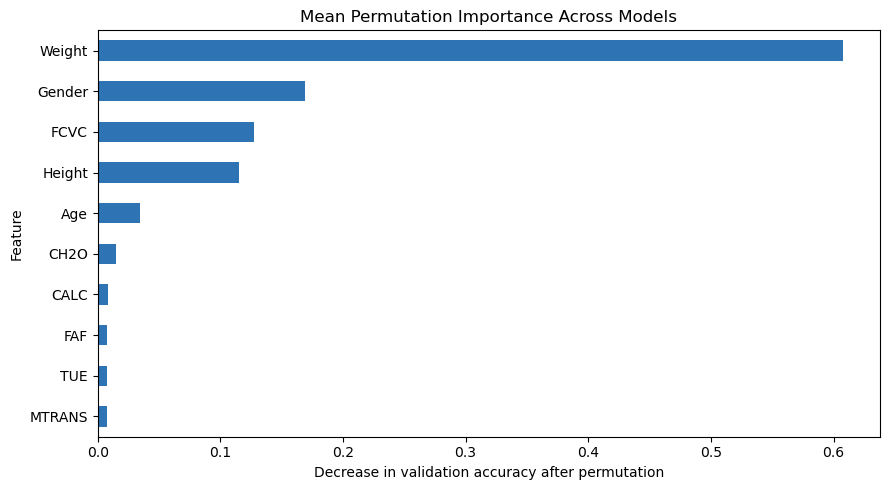

In [6]:
importance = pd.DataFrame(importance_records)
top = (importance.sort_values(["Model", "Mean importance"], ascending=[True, False])
       .groupby("Model").head(6))
display(top.round(4))

plot_imp = (importance.groupby("Feature")["Mean importance"].mean()
            .sort_values(ascending=False).head(10).sort_values())
plot_imp.plot(kind="barh", figsize=(9, 5), color="#2E74B5")
plt.title("Mean Permutation Importance Across Models")
plt.xlabel("Decrease in validation accuracy after permutation")
plt.tight_layout()
plt.show()

### Model interpretation

Weight is dominant in every model; gender, height, vegetable-consumption frequency (`FCVC`), and age are consistently influential.  Permutation importance is predictive rather than causal:  correlated body-size variables can substitute for one another, and importance may reflect how the synthetic target was constructed.  The dominance of weight and height also raises a leakage-like concern:  because obesity classes are closely tied to body-mass index, the task may partly reconstruct the label definition rather than discover independent behavioral causes.

## Final training and Kaggle submission files

In [7]:
submission_paths = {}
for name, classifier in models.items():
    final_model = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("model", classifier),
    ])
    final_model.fit(X, y_encoded)
    test_prediction = label_encoder.inverse_transform(final_model.predict(X_test))
    submission = sample_submission.copy()
    submission[TARGET] = test_prediction
    filename = name.lower().replace(" ", "_") + "_submission.csv"
    path = SUBMISSION_DIR / filename
    submission.to_csv(path, index=False)
    submission_paths[name] = path

display(pd.DataFrame({
    "Model": submission_paths.keys(),
    "Submission file": [str(p) for p in submission_paths.values()],
}))

,Model,Submission file
0,Decision tree,obesity_submissions\decision_tree_submission.csv
1,Bagging,obesity_submissions\bagging_submission.csv
2,Random forest,obesity_submissions\random_forest_submission.csv
3,Boosted,obesity_submissions\boosted_submission.csv


## Successful Kaggle submissions

All four files were accepted as late submissions on August 16, 2026.  The public and private scores closely track local validation, and all four complete the required submission workflow.

,Model,Local accuracy,Kaggle public,Kaggle private,Status
0,Boosted,0.90920,0.90498,0.90290,Complete (after deadline)
1,Bagging,0.90005,0.89486,0.89477,Complete (after deadline)
2,Random forest,0.89523,0.89234,0.89342,Complete (after deadline)
3,Decision tree,0.87572,0.87391,0.87039,Complete (after deadline)


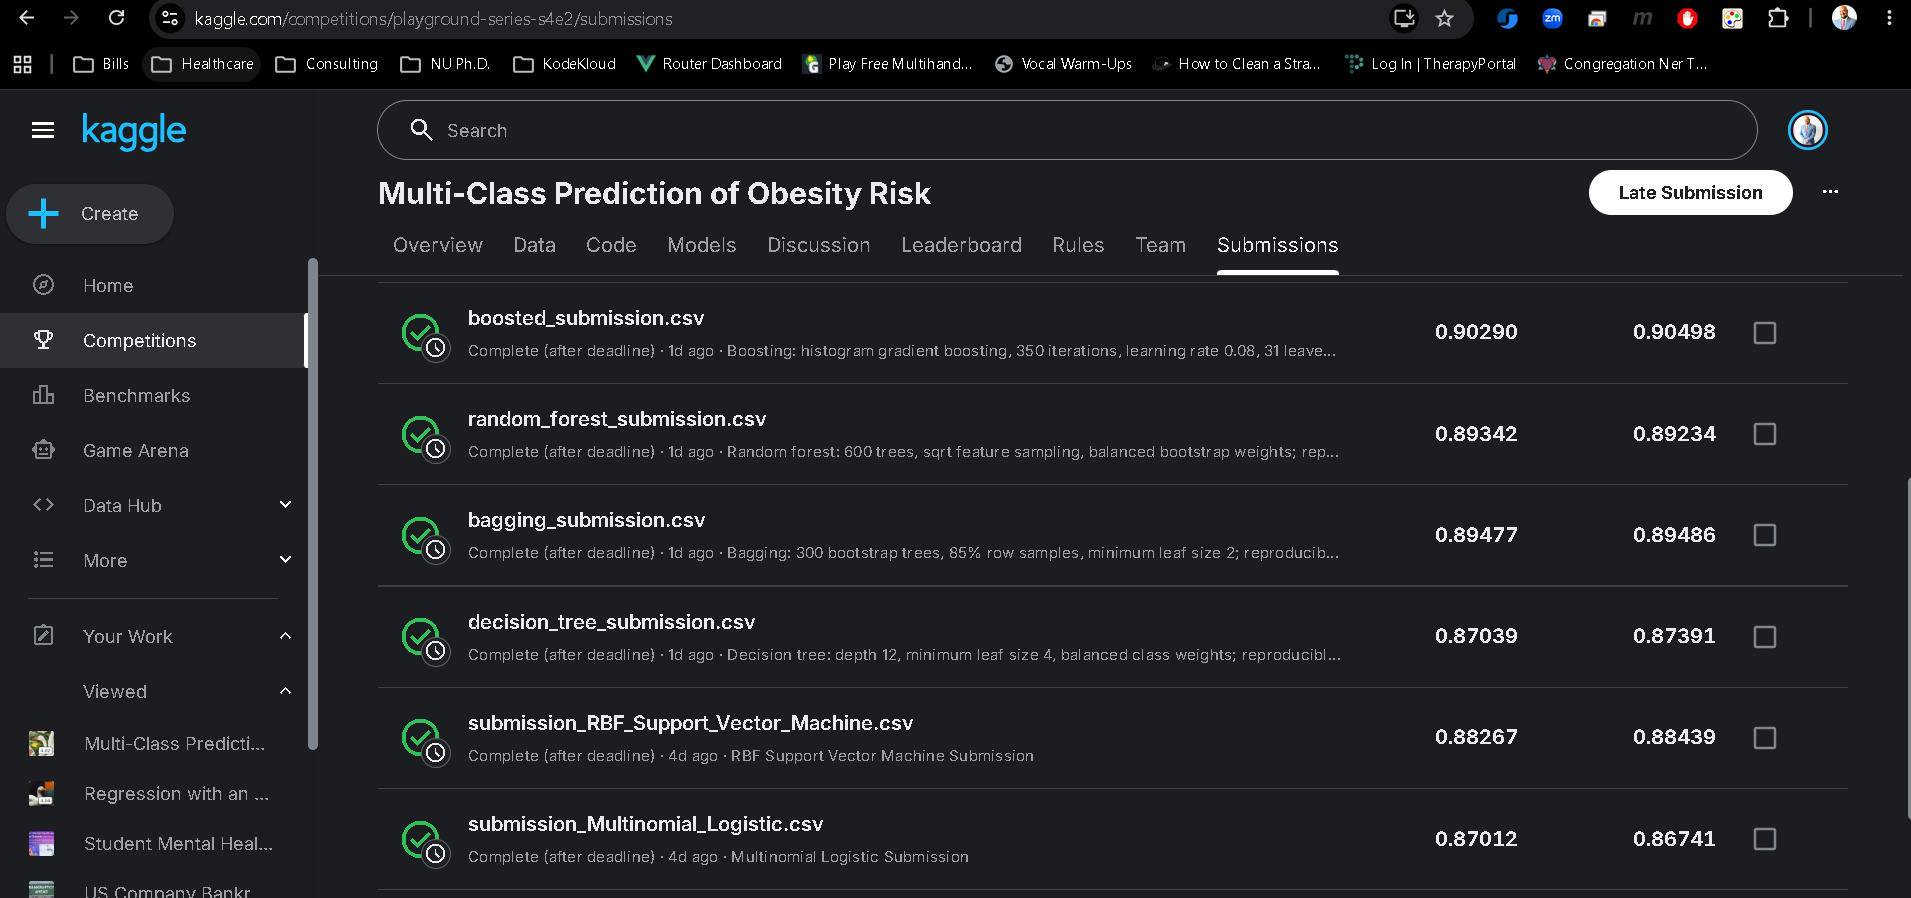

In [8]:
kaggle_results = pd.DataFrame({
    "Model": ["Boosted", "Bagging", "Random forest", "Decision tree"],
    "Local accuracy": [0.90920, 0.90005, 0.89523, 0.87572],
    "Kaggle public": [0.90498, 0.89486, 0.89234, 0.87391],
    "Kaggle private": [0.90290, 0.89477, 0.89342, 0.87039],
    "Status": ["Complete (after deadline)"] * 4,
})
display(kaggle_results.round({
    "Local accuracy": 5, "Kaggle public": 5,
    "Kaggle private": 5,
}))
display(Image(filename="kaggle_scores.png", width=900))

## Overall interpretation and limitations

The boosted model is the clear winner: its 0.90498 public and 0.90290 private Kaggle scores exceed bagging (0.89486/0.89477), random forest (0.89234/0.89342), and the decision tree (0.87391/0.87039).  The ranking exactly matches local validation, and the boosted model's local-to-private difference is only 0.0063, supporting the representativeness of the split.

The analysis does **not** establish that these predictors cause obesity, that errors are clinically harmless, or that performance transfers to other countries, ages, or measurement processes.  The source study included young adults from Colombia, Mexico, and Peru, and the Kaggle data are synthetic.  Ethical deployment would require external validation, subgroup performance analysis, calibration, privacy safeguards, and clinician-defined consequences for ordinal misclassification.  These constraints are more important than a small leaderboard gain.

## Code Availability

The complete Jupyter notebook and supporting project materials are publicly available in the [Predictive Analytics repository on GitHub](https://github.com/perezrd5/Predictive-Analytics).

## References

Breiman, L. (2001). Random forests. *Machine Learning, 45*, 5–32. https://doi.org/10.1023/A:1010933404324

Costa, R. M., et al. (2024). Does machine learning have a high performance to predict obesity among adults and older adults? A systematic review and meta-analysis. *Nutrition, Metabolism and Cardiovascular Diseases, 34*(9), 2034–2045. https://doi.org/10.1016/j.numecd.2024.05.020

Palechor, F. M., & de la Hoz Manotas, A. (2019). Dataset for estimation of obesity levels based on eating habits and physical condition in individuals from Colombia, Peru and Mexico. *Data in Brief, 25*, 104344. https://doi.org/10.1016/j.dib.2019.104344

Related application: Palechor, F. M., & de la Hoz Manotas, A. (2020). Estimation of obesity levels based on computational intelligence. *Informatics in Medicine Unlocked, 21*, 100472. https://doi.org/10.1016/j.imu.2020.100472